In [11]:
import pandas as pd
import numpy as np
from pymongo import MongoClient
df = pd.read_csv(r"C:\Users\Srashthi\Downloads\streamingplatform.csv")
df.head()
df.info()
df.describe()
client = MongoClient('mongodb://localhost:27017/')
db = client["music_streaming"]
collection = db["streams"]
collection.insert_many(df.to_dict('records'))
collection.count_documents({})

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Index              998 non-null    int64 
 1   SongID             998 non-null    object
 2   TimeStamp_Central  998 non-null    object
 3   Performer          998 non-null    object
 4   Album              998 non-null    object
 5   Song               998 non-null    object
 6   TimeStamp_UTC      998 non-null    object
dtypes: int64(1), object(6)
memory usage: 54.7+ KB


13972

In [12]:
pipeline = [
    {"$match": {"Performer": "Adele"}},
    {"$group": {"_id": "$Song", "count": {"$sum": 1}}}
]

results = collection.aggregate(pipeline)

for song in results:
    print(f"Song: {song['_id']}, Count: {song['count']}")


In [13]:
df.head()

,Index,SongID,TimeStamp_Central,Performer,Album,Song,TimeStamp_UTC
0,1,Devil's EyesGreyhounds,5/25/2021 5:15:00 PM,Greyhounds,Change of Pace,Devil's Eyes,5/25/2021 11:15:00 PM
1,2,Pussy and PizzaMurs,5/25/2021 5:12:00 PM,Murs,Have a Nice Life,Pussy and Pizza,5/25/2021 11:12:00 PM
2,3,Opera (feat. Method Man)King Green,5/25/2021 5:08:00 PM,King Green,Opera (feat. Method Man),Opera (feat. Method Man),5/25/2021 11:08:00 PM
3,4,Sweet PotatoMouthe,5/25/2021 5:05:00 PM,Mouthe,NUVO,Sweet Potato,5/25/2021 11:05:00 PM
4,5,Meanwhile Back in the CityThe Presidents of th...,5/25/2021 5:01:00 PM,The Presidents of the United States of America,Freaked Out And Small,Meanwhile Back in the City,5/25/2021 11:01:00 PM


In [14]:
import pandas as pd

# Retrieve data from MongoDB
records = list(collection .find())

# Convert to DataFrame
df = pd.DataFrame(records)

# Convert timestamps to datetime format
df["TimeStamp_Central"] = pd.to_datetime(df["TimeStamp_Central"])
df["TimeStamp_UTC"] = pd.to_datetime(df["TimeStamp_UTC"])

print(df.head())  # Display the first few rows


C:\Users\Srashthi\AppData\Local\Temp\ipykernel_24460\1081428189.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TimeStamp_Central"] = pd.to_datetime(df["TimeStamp_Central"])
C:\Users\Srashthi\AppData\Local\Temp\ipykernel_24460\1081428189.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TimeStamp_UTC"] = pd.to_datetime(df["TimeStamp_UTC"])


                        _id  Index  \
0  67f2875033025d317e65d632      1   
1  67f2875033025d317e65d633      2   
2  67f2875033025d317e65d634      3   
3  67f2875033025d317e65d635      4   
4  67f2875033025d317e65d636      5   

                                              SongID   TimeStamp_Central  \
0                             Devil's EyesGreyhounds 2021-05-25 17:15:00   
1                                Pussy and PizzaMurs 2021-05-25 17:12:00   
2                 Opera (feat. Method Man)King Green 2021-05-25 17:08:00   
3                                 Sweet PotatoMouthe 2021-05-25 17:05:00   
4  Meanwhile Back in the CityThe Presidents of th... 2021-05-25 17:01:00   

                                        Performer                     Album  \
0                                      Greyhounds            Change of Pace   
1                                            Murs          Have a Nice Life   
2                                      King Green  Opera (feat. Method Man)  

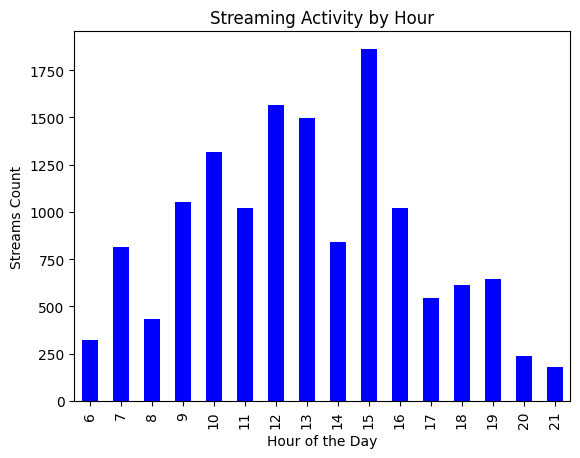

In [18]:
import matplotlib.pyplot as plt

# Extract hour from timestamp
df["stream_hour"] = df["TimeStamp_Central"].dt.hour

# Plot streaming activity by hour
df["stream_hour"].value_counts().sort_index().plot(kind="bar", color="blue")
plt.title("Streaming Activity by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Streams Count")
plt.show()


In [19]:
performer_name = "Artist Name"
songs_by_performer = collection.find({"Performer": performer_name})

for song in songs_by_performer:
    print(song)


ServerSelectionTimeoutError: localhost:27017: [WinError 10061] No connection could be made because the target machine actively refused it (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms), Timeout: 30s, Topology Description: <TopologyDescription id: 696f28a0c95ee7ce5d7895a4, topology_type: Single, servers: [<ServerDescription ('localhost', 27017) server_type: Unknown, rtt: None, error=AutoReconnect('localhost:27017: [WinError 10061] No connection could be made because the target machine actively refused it (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms)')>]>

In [ ]:

sorted_songs = collection.find().sort("TimeStamp_UTC", 1) 

for song in sorted_songs:
    print(song)


In [ ]:
pipeline = [
    {"$group": {"_id": "$Performer", "totalSongs": {"$sum": 1}}}
]

performer_song_count = collection.aggregate(pipeline)

for performer in performer_song_count:
    print(performer)


In [ ]:
from datetime import datetime
import pytz

# Define Central Time Zone
central_tz = pytz.timezone('US/Central')

# Convert a timestamp string to datetime in Central Time
central_time_str = "2025-04-08T14:00:00"
central_time = datetime.strptime(central_time_str, '%Y-%m-%dT%H:%M:%S')
central_time = central_tz.localize(central_time)

# Convert to UTC
utc_time = central_time.astimezone(pytz.utc)
print("UTC Time:", utc_time)


In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity



# Convert timestamp to datetime.
df['TimeStamp_Central'] = pd.to_datetime(
    df['TimeStamp_Central'],
    format='%m/%d/%Y %I:%M:%S %p',
    errors='coerce'
)

# Create a unique song label.
df['UniqueSong'] = df['Performer'] + " - " + df['Song']

# Create user-song interaction matrix (count of plays)
user_song_matrix = df.pivot_table(
    index='SongID',
    columns='UniqueSong',
    values='TimeStamp_Central',
    aggfunc='count',
    fill_value=0
)

from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity between songs
song_similarity = cosine_similarity(user_song_matrix.T)

# Create a DataFrame of the similarities
similarity_df = pd.DataFrame(song_similarity, index=user_song_matrix.columns, columns=user_song_matrix.columns)



In [ ]:
from difflib import get_close_matches

def recommend_songs_fuzzy(song_name, similarity_df, top_n=3):
    all_songs = similarity_df.columns
    close_matches = get_close_matches(song_name, all_songs, n=1, cutoff=0.6)
    
    if not close_matches:
        return f"No similar song name found for '{song_name}'."
    
    matched_song = close_matches[0]
    similar_songs = similarity_df[matched_song].sort_values(ascending=False)[1:top_n+1]
    return list(similar_songs.index)


In [ ]:
print(recommend_songs_fuzzy(" Devil's Eyes", similarity_df))


In [ ]:
# Fetch all data
data = list(collection.find())

# Load into DataFrame
import pandas as pd
df = pd.DataFrame(data)


In [ ]:
df.head

In [ ]:
collection.find({"Performer": "Hippie Sabotage"})


In [ ]:
collection.update_one(
    {"SongID": "S001"},
    {"$set": {"Song": "Devil's Eyes (Remix)"}}
)


In [ ]:
pipeline = [
    {"$group": {"_id": "$Song", "Count": {"$sum": 1}}},
    {"$sort": {"Count": -1}},
    {"$limit": 5}
]


In [ ]:
pipeline = [
    {"$group": {"_id": "$Song", "Count": {"$sum": 1}}},
    {"$sort": {"Count": -1}},
    {"$limit": 5}
]

user_top_songs = list(collection.aggregate(pipeline))


In [ ]:
pipeline = [
    {"$project": {
        "hour": {"$hour": {"$dateFromString": {"dateString": "$TimeStamp_Central"}}}
    }},
    {"$group": {
        "_id": "$hour",
        "StreamCount": {"$sum": 1}
    }},
    {"$sort": {"_id": 1}}
]

stream_by_hour = list(collection.aggregate(pipeline))


In [ ]:
pipeline = [
    {"$project": {
        "hour": {"$hour": {"$dateFromString": {"dateString": "$TimeStamp_Central"}}}
    }},
    {"$group": {
        "_id": "$hour",
        "StreamCount": {"$sum": 1}
    }},
    {"$sort": {"_id": 1}}
]

stream_by_hour = list(collection.aggregate(pipeline))


In [ ]:
pipeline = [
    {
        "$project": {
            "hour": {
                "$hour": {
                    "$dateFromString": { "dateString": "$TimeStamp_Central" }
                }
            }
        }
    },
    {
        "$group": {
            "_id": "$hour",
            "performer": { "$sum": 1 }
        }
    },
    {
        "$sort": { "_id": 1 }
    }
]


In [ ]:
pipeline = [
    {"$match": {"Performer": "Adele"}},
    {"$group": {"_id": "$Song", "count": {"$sum": 1}}}
]


In [ ]:
import pandas as pd
from pymongo import MongoClient

uri = "mongodb://localhost:27017/"
client = MongoClient(uri)

db = client["music_db"]

# Example collections
users = pd.DataFrame(list(db.users.find()))
songs = pd.DataFrame(list(db.songs.find()))
reco = pd.DataFrame(list(db.recommendations.find()))

# Remove MongoDB _id
for df in [users, songs, reco]:
    if "_id" in df.columns:
        df.drop("_id", axis=1, inplace=True)

# Save to CSV
users.to_csv("users.csv", index=False)
songs.to_csv("songs.csv", index=False)
reco.to_csv("recommendations.csv", index=False)


In [20]:
import os
print(os.getcwd())


C:\Users\Srashthi
